In [6]:
!mamba install scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.672 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.5.20                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.15                          pyhcf101f3_0                  conda-forge                   
+ joblib                        1.5.3    

In [4]:
!mamba install seaborn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.47230000007152556 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ patsy                         1.0.2                         py313h1804a44_1               emscripten-forge              
+ seaborn                       0.13.2                        hd8ed1ab_3                    conda-forge                   
+ seaborn-base                  0.13.2                        pyhd8ed1ab_3                  conda-forge                   
+ statsmodels                   0.14.6                        np22py313h3cf259a_1           emscripten-forge              


In [2]:
!mamba install pandas

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.2578000000715255 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.2                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)

plt.rcParams['figure.dpi'] = 150

In [8]:
df = pd.read_csv("Social_Network_Ads.csv")

print(f"Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
print(f"\nSınıf dağılımı (Purchased):")
print(df['Purchased'].value_counts().to_string())

df = df.drop('User ID', axis=1)

# (Male: 1, Female: 0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

print(f"\nÖn işleme sonrası ilk 5 satır:")
display(df.head())

Veri seti boyutu: 400 satır, 5 sütun

Sınıf dağılımı (Purchased):
Purchased
0    257
1    143

Ön işleme sonrası ilk 5 satır:


,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


In [11]:
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

print(f"Özellik matrisi (X): {X.shape}")
print(f"Hedef vektör (y):   {y.shape}")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Özellik matrisi (X): (400, 3)
Hedef vektör (y):   (400,)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

# Test seti üzerinde tahmin yap
log_pred = log_model.predict(X_test_scaled)

print("=== LOJİSTİK REGRESYON SONUÇLARI ===")
print(f"Accuracy Score: {accuracy_score(y_test, log_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, log_pred))

=== LOJİSTİK REGRESYON SONUÇLARI ===
Accuracy Score: 0.8875

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



In [14]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# Test seti üzerinde tahmin yap
tree_pred = tree_model.predict(X_test)

print("=== KARAR AĞACI SONUÇLARI ===")
print(f"Accuracy Score: {accuracy_score(y_test, tree_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, tree_pred))

=== KARAR AĞACI SONUÇLARI ===
Accuracy Score: 0.9125

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93        52
           1       0.86      0.89      0.88        28

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.90        80
weighted avg       0.91      0.91      0.91        80



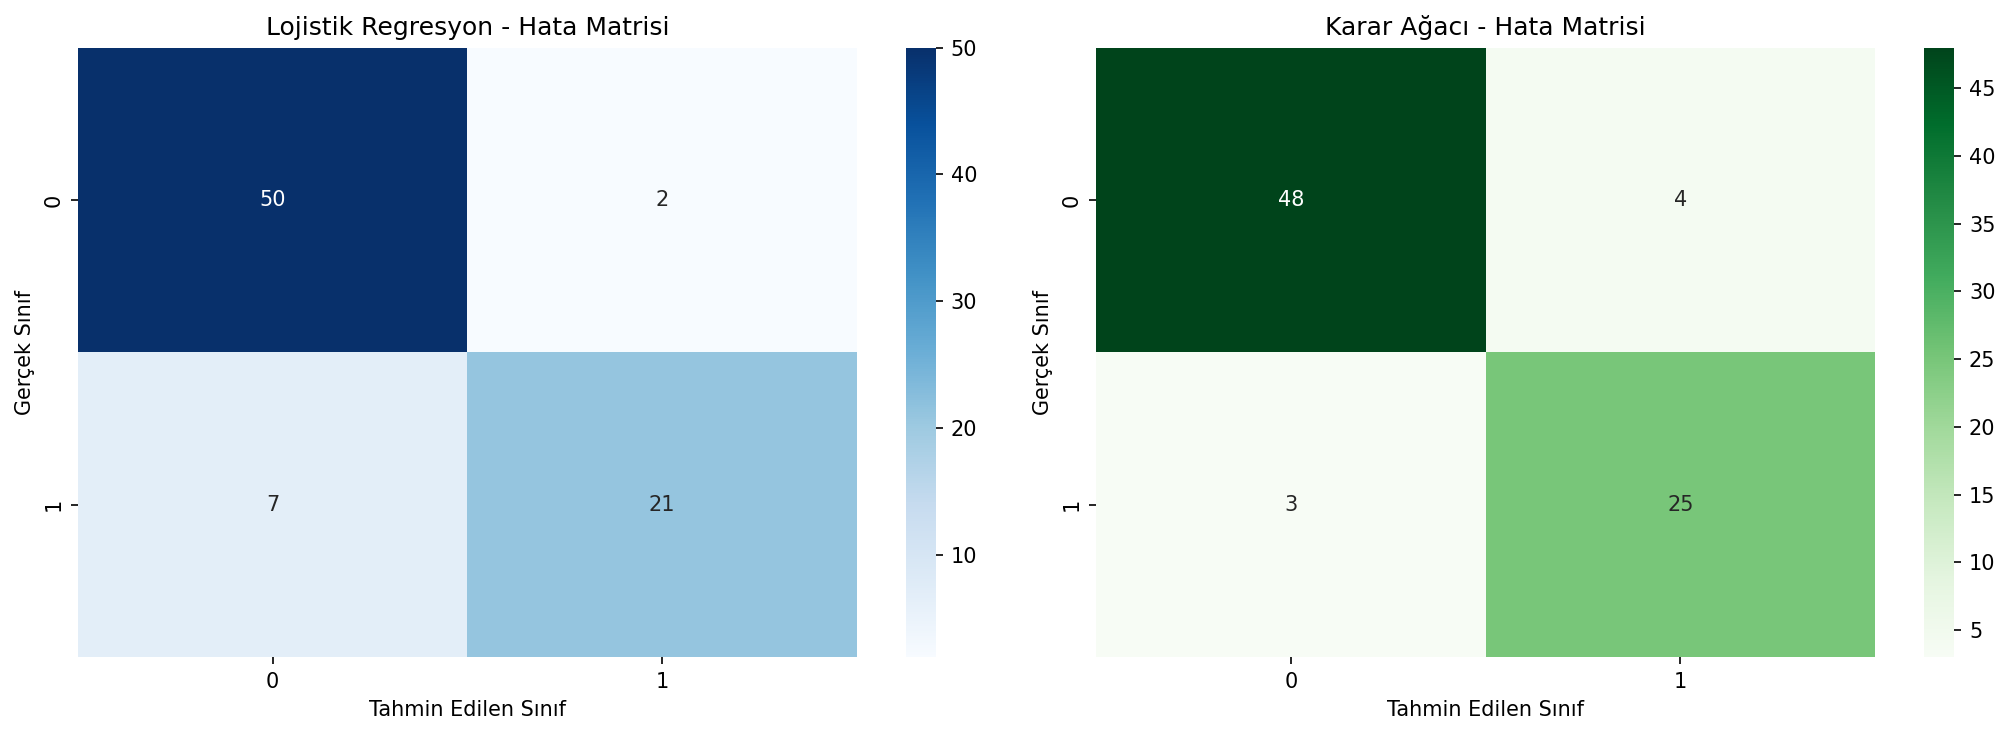

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lojistik Regresyon Hata Matrisi
sns.heatmap(confusion_matrix(y_test, log_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Lojistik Regresyon - Hata Matrisi')
axes[0].set_xlabel('Tahmin Edilen Sınıf')
axes[0].set_ylabel('Gerçek Sınıf')

# Karar Ağacı Hata Matrisi
sns.heatmap(confusion_matrix(y_test, tree_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Karar Ağacı - Hata Matrisi')
axes[1].set_xlabel('Tahmin Edilen Sınıf')
axes[1].set_ylabel('Gerçek Sınıf')

plt.tight_layout()
plt.show()

=== DETAYLI PERFORMANS KARŞILAŞTIRMASI ===



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Lojistik Regresyon,0.8875,0.9130,0.7500,0.8235,0.9705
1,Karar Ağacı,0.9125,0.8621,0.8929,0.8772,0.9574


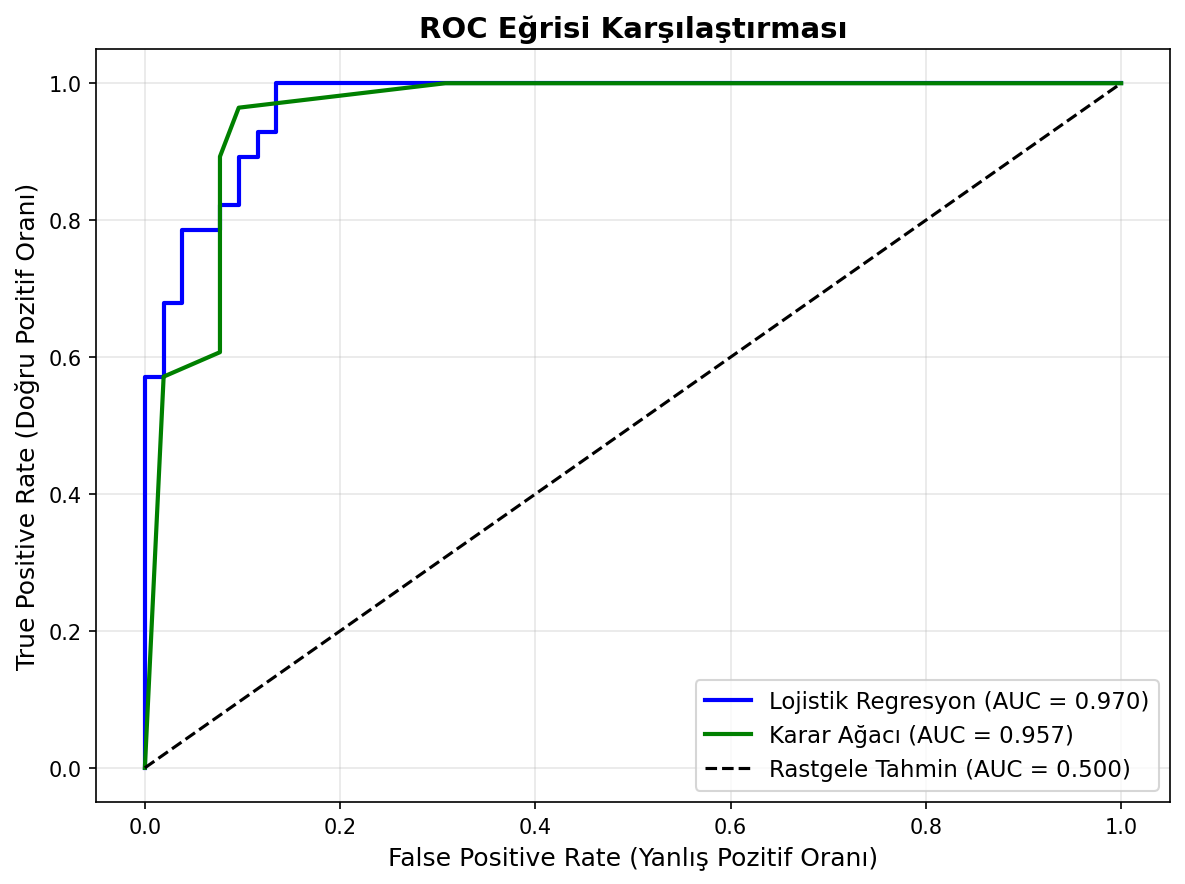

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_score, recall_score, f1_score

# 1. Modellerin Olasılık (Probability) Tahminlerini Al (ROC için gerekli)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]
tree_prob = tree_model.predict_proba(X_test)[:, 1]

# 2. Performans Metriklerini Hesapla ve Tabloya Dönüştür
metrics = {
    'Model': ['Lojistik Regresyon', 'Karar Ağacı'],
    'Accuracy': [accuracy_score(y_test, log_pred), accuracy_score(y_test, tree_pred)],
    'Precision': [precision_score(y_test, log_pred), precision_score(y_test, tree_pred)],
    'Recall': [recall_score(y_test, log_pred), recall_score(y_test, tree_pred)],
    'F1-Score': [f1_score(y_test, log_pred), f1_score(y_test, tree_pred)],
    'ROC-AUC': [roc_auc_score(y_test, log_prob), roc_auc_score(y_test, tree_prob)]
}

metrics_df = pd.DataFrame(metrics)

print("=== DETAYLI PERFORMANS KARŞILAŞTIRMASI ===\n")
display(metrics_df.round(4)) # Sonuçları 4 ondalık basamakla göster

# 3. ROC Eğrilerini Hesapla
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_prob)

# 4. ROC Eğrilerini Çizdir
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Lojistik Regresyon (AUC = {metrics["ROC-AUC"][0]:.3f})', color='blue', linewidth=2)
plt.plot(fpr_tree, tpr_tree, label=f'Karar Ağacı (AUC = {metrics["ROC-AUC"][1]:.3f})', color='green', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin (AUC = 0.500)') # Çapraz referans çizgisi

# Grafik Ayarları
plt.title('ROC Eğrisi Karşılaştırması', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)', fontsize=12)
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()